<a href="https://colab.research.google.com/github/Jessicadollz/Insight-Flow-SQL-Analytics/blob/master/Insight_Flow_SQL_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DATA LOADING

In [41]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

# Show shapes
pd.DataFrame({
    "Table": ["orders", "customers", "order_items", "payments", "products"],
    "Rows": [orders.shape[0], customers.shape[0], order_items.shape[0], payments.shape[0], products.shape[0]],
    "Columns": [orders.shape[1], customers.shape[1], order_items.shape[1], payments.shape[1], products.shape[1]]
})

,Table,Rows,Columns
0,orders,99441,8
1,customers,99441,5
2,order_items,112650,7
3,payments,103886,5
4,products,32951,9


2. DATA CLEANING


In [42]:
# BEFORE cleaning
before_missing = orders.isnull().sum().reset_index()
before_missing.columns = ["Column", "Missing Values"]

before_missing

,Column,Missing Values
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,160
5,order_delivered_carrier_date,1783
6,order_delivered_customer_date,2965
7,order_estimated_delivery_date,0


In [43]:
# Cleaning steps
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders = orders.dropna(subset=['order_delivered_customer_date'])
orders = orders.drop_duplicates()

# AFTER cleaning
after_missing = orders.isnull().sum().reset_index()
after_missing.columns = ["Column", "Missing Values"]

after_missing

,Column,Missing Values
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,14
5,order_delivered_carrier_date,1
6,order_delivered_customer_date,0
7,order_estimated_delivery_date,0


In [44]:
# Show dataset size AFTER cleaning
pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Rows": [99441, orders.shape[0]]  # you can adjust if needed
})

,Stage,Rows
0,Before Cleaning,99441
1,After Cleaning,96476


3. DATA PIPELINE (SQL Tables OUTPUT)

In [45]:
import sqlite3
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False)
customers.to_sql('customers', conn, index=False)
order_items.to_sql('order_items', conn, index=False)
payments.to_sql('payments', conn, index=False)
products.to_sql('products', conn, index=False)

# Show tables created
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,orders
1,customers
2,order_items
3,payments
4,products


4. FEATURE ENGINEERING (Payments Aggregation OUTPUT)

In [46]:
conn.execute("""
CREATE TABLE payments_agg AS
SELECT order_id, SUM(payment_value) AS total_payment
FROM payments
GROUP BY order_id;
""")

# Show result
pd.read_sql("SELECT * FROM payments_agg LIMIT 5;", conn)

,order_id,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


5. DATA MERGING

In [47]:
conn.execute("""
CREATE TABLE fact_orders AS
SELECT
    o.order_id,
    o.customer_id,
    c.customer_city,
    c.customer_state,
    oi.product_id,
    oi.price,
    oi.freight_value,
    p.total_payment,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN payments_agg p ON o.order_id = p.order_id;
""")

# Show final table
pd.read_sql("SELECT * FROM fact_orders LIMIT 5;", conn)

,order_id,customer_id,customer_city,customer_state,product_id,price,freight_value,total_payment,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,141.46,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,159.90,19.22,179.12,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,72.20,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,28.62,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00


6. FEATURE ENGINEERING (Delivery Delay OUTPUT)

In [48]:
pd.read_sql("""
SELECT order_id,
       total_payment,
       julianday(order_delivered_customer_date) -
       julianday(order_estimated_delivery_date) AS delivery_delay
FROM fact_orders
LIMIT 5;
""", conn)

,order_id,total_payment,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,-9.238171


7. FINAL RESULTS (VISIBLE OUTPUT)

In [49]:
#TOTAL REVENUE

pd.read_sql("SELECT SUM(total_payment) AS total_revenue FROM fact_orders;", conn)

,total_revenue
0,1.977567e+07


In [50]:
#TOP CUSTOMERS

pd.read_sql("""
SELECT customer_id, SUM(total_payment) AS revenue
FROM fact_orders
GROUP BY customer_id
ORDER BY revenue DESC
LIMIT 5;
""", conn)

,customer_id,revenue
0,1617b1357756262bfa56ab541c47bc16,109312.64
1,bd5d39761aa56689a265d95d8d32b8be,45256.00
2,be1b70680b9f9694d8c70f41fa3dc92b,44048.00
3,05455dfa7cd02f13d132aa7a6a9729c6,36489.24
4,1ff773612ab8934db89fd5afa8afe506,30186.00


In [51]:
#ORDERS COUNT

pd.read_sql("SELECT COUNT(*) AS total_orders FROM fact_orders;", conn)

,total_orders
0,110193


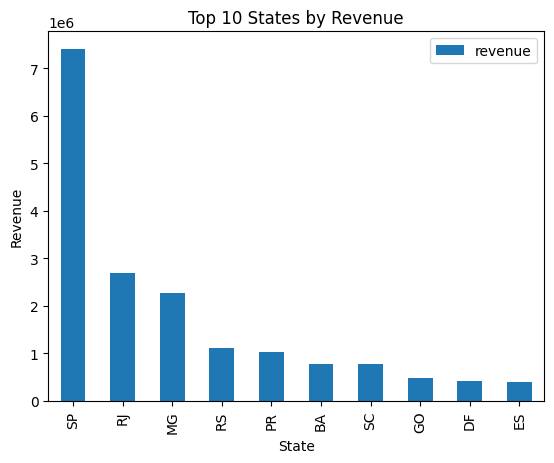

In [52]:
#REVENUE BY STATE

import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT customer_state, SUM(total_payment) AS revenue
FROM fact_orders
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10;
""", conn)

df.plot(kind='bar', x='customer_state', y='revenue')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

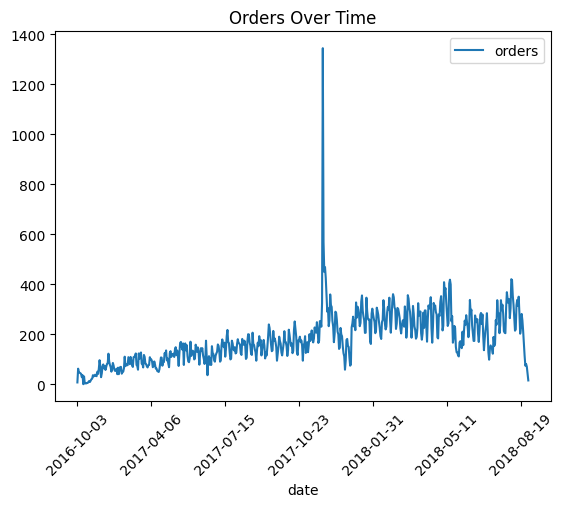

In [53]:
#ORDERS OVER TIME

df = pd.read_sql("""
SELECT DATE(order_purchase_timestamp) AS date, COUNT(*) AS orders
FROM fact_orders
GROUP BY date
ORDER BY date;
""", conn)

df.plot(x='date', y='orders')

plt.title("Orders Over Time")
plt.xticks(rotation=45)
plt.show()

RFM ANALYSIS

In [54]:
#Create RFM Table

rfm = pd.read_sql("""
SELECT
    customer_id,
    MAX(order_purchase_timestamp) AS last_purchase,
    COUNT(order_id) AS frequency,
    SUM(total_payment) AS monetary
FROM fact_orders
GROUP BY customer_id;
""", conn)

rfm.head()

,customer_id,last_purchase,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01


In [55]:
#Calculate Recency

# Convert last_purchase to datetime
rfm['last_purchase'] = pd.to_datetime(rfm['last_purchase'])

# Make sure 'today' is also datetime
today = pd.to_datetime(rfm['last_purchase'].max())

# Calculate recency
rfm['recency'] = (today - rfm['last_purchase']).dt.days

# Show output
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,287
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,409
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,547
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,378
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,149


In [56]:
#Score Customers

rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1], duplicates='drop')
rfm['F_score'] = pd.cut(rfm['frequency'], bins=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4], duplicates='drop')

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_Score
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,287,2,1,3,213
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,409,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,547,1,1,3,113
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,378,1,1,3,113
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,149,3,1,2,312


In [57]:
#Show top customers

rfm.sort_values(by='monetary', ascending=False).head(10)

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_Score
8293,1617b1357756262bfa56ab541c47bc16,2017-09-29 15:24:52,8,109312.64,333,2,2,4,224
71681,bd5d39761aa56689a265d95d8d32b8be,2017-08-23 09:22:34,20,45256.00,371,1,4,4,144
71931,be1b70680b9f9694d8c70f41fa3dc92b,2018-02-22 15:30:41,20,44048.00,187,3,4,4,344
2007,05455dfa7cd02f13d132aa7a6a9729c6,2017-11-24 11:03:35,6,36489.24,278,2,1,4,214
12045,1ff773612ab8934db89fd5afa8afe506,2018-04-19 13:54:06,10,30186.00,132,3,2,4,324
89273,ec5b2ba62e574342386871631fafd3fc,2018-07-15 14:49:44,4,29099.52,45,4,1,4,414
87589,e7d6802668de6e74d0d6c56565bf2a24,2017-10-02 15:49:23,10,22346.60,330,2,2,4,224
52722,8c20d9bfbc96c5d39025d77a3ba83d7f,2018-02-01 18:32:02,11,21874.05,208,3,2,4,324
93314,f7622098214b4634b7fe7eee269b5426,2018-06-01 19:08:41,6,19457.04,88,4,1,4,414
42626,71901689c5f3e5adc27b1dd16b33f0b8,2018-05-22 13:43:23,6,19174.38,99,4,1,4,414


TALK-TO-SQL

In [58]:
#Create Function

def ask_question(question):
    if "total revenue" in question.lower():
        query = "SELECT SUM(total_payment) AS total_revenue FROM fact_orders;"

    elif "top customers" in question.lower():
        query = """
        SELECT customer_id, SUM(total_payment) AS revenue
        FROM fact_orders
        GROUP BY customer_id
        ORDER BY revenue DESC
        LIMIT 5;
        """

    elif "orders count" in question.lower():
        query = "SELECT COUNT(*) AS total_orders FROM fact_orders;"

    else:
        return "Sorry, I don't understand the question."

    return pd.read_sql(query, conn)

In [59]:
ask_question("top customers")

,customer_id,revenue
0,1617b1357756262bfa56ab541c47bc16,109312.64
1,bd5d39761aa56689a265d95d8d32b8be,45256.00
2,be1b70680b9f9694d8c70f41fa3dc92b,44048.00
3,05455dfa7cd02f13d132aa7a6a9729c6,36489.24
4,1ff773612ab8934db89fd5afa8afe506,30186.00
